In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import mlflow
import mlflow.lightgbm
import joblib
import warnings
warnings.filterwarnings('ignore')

# Load data
train = pd.read_csv('data/train_features.csv', low_memory=False)
test  = pd.read_csv('data/test_features.csv',  low_memory=False)
train['Date'] = pd.to_datetime(train['Date'])
test['Date']  = pd.to_datetime(test['Date'])

# Load features list and model
FEATURES = joblib.load('models/features.pkl')
model    = joblib.load('models/lgbm_model.pkl')

print("Everything loaded!")

Everything loaded!


In [2]:
# RMSPE metric
def rmspe(y_true, y_pred):
    y_true = np.expm1(y_true)
    y_pred = np.expm1(y_pred)
    mask   = y_true != 0
    return np.sqrt(np.mean(((y_true[mask] - y_pred[mask])
                             / y_true[mask]) ** 2))

# Prepare split
TARGET   = 'LogSales'
val_date = '2015-06-01'
train[TARGET] = np.log1p(train['Sales'])

X_train = train[train['Date'] <  val_date][FEATURES]
y_train = train[train['Date'] <  val_date][TARGET]
X_val   = train[train['Date'] >= val_date][FEATURES]
y_val   = train[train['Date'] >= val_date][TARGET]

print("Data ready!")

Data ready!


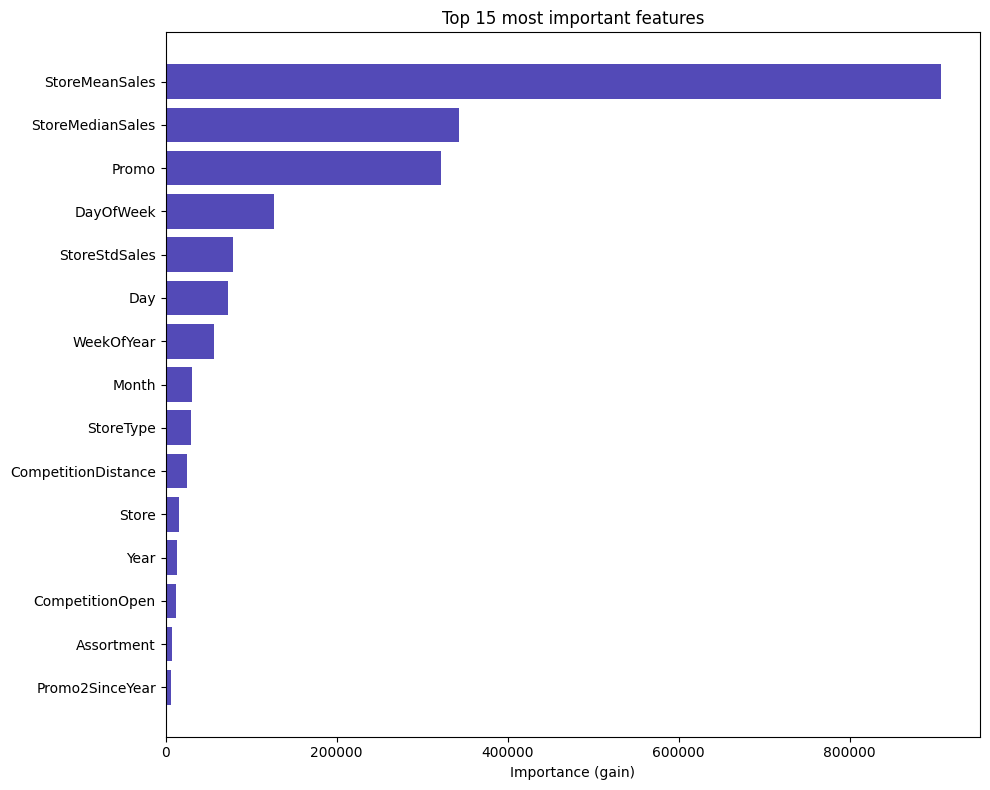

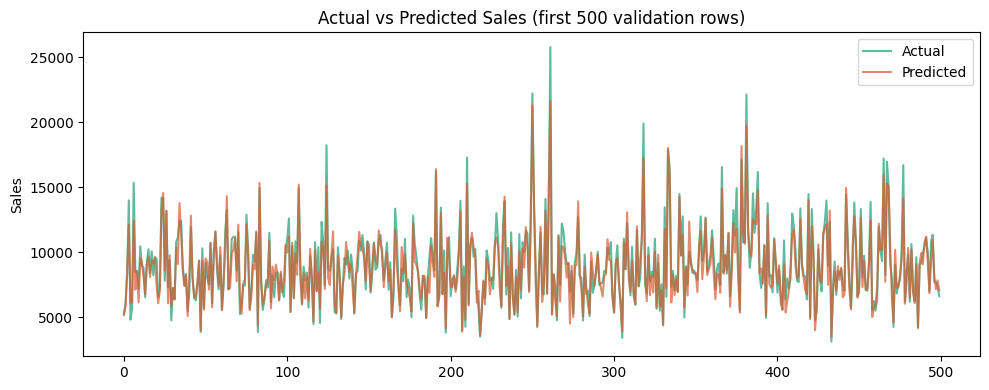

2026/05/02 14:33:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Run logged!
Train RMSPE : 0.1082
Val RMSPE   : 0.1383


In [5]:
# Set up MLflow experiment
mlflow.set_experiment("rossmann-sales-forecasting")

with mlflow.start_run(run_name="lgbm_final"):

    # Log parameters
    mlflow.log_param("model_type",       "LightGBM")
    mlflow.log_param("num_leaves",       128)
    mlflow.log_param("learning_rate",    0.03)
    mlflow.log_param("num_boost_round",  model.num_trees())
    mlflow.log_param("val_split_date",   val_date)
    mlflow.log_param("num_features",     len(FEATURES))

    # Calculate and log metrics
    train_preds = model.predict(X_train)
    val_preds   = model.predict(X_val)
    train_rmspe = rmspe(y_train.values, train_preds)
    val_rmspe   = rmspe(y_val.values,   val_preds)

    mlflow.log_metric("train_rmspe", round(train_rmspe, 4))
    mlflow.log_metric("val_rmspe",   round(val_rmspe,   4))

    # Log feature importance chart
    importance = pd.DataFrame({
        'Feature'   : FEATURES,
        'Importance': model.feature_importance(importance_type='gain')
    }).sort_values('Importance', ascending=False)

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(importance['Feature'][:15],
            importance['Importance'][:15], color='#534AB7')
    ax.set_xlabel('Importance (gain)')
    ax.set_title('Top 15 most important features')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig('data/feature_importance.png', dpi=150)
    mlflow.log_artifact('data/feature_importance.png')
    plt.show()

    # Log actual vs predicted chart
    fig2, ax2 = plt.subplots(figsize=(10, 4))
    sample = 500
    ax2.plot(np.expm1(y_val.values[:sample]),
             label='Actual', alpha=0.7, color='#1D9E75')
    ax2.plot(np.expm1(val_preds[:sample]),
             label='Predicted', alpha=0.7, color='#D85A30')
    ax2.set_title('Actual vs Predicted Sales (first 500 validation rows)')
    ax2.set_ylabel('Sales')
    ax2.legend()
    plt.tight_layout()
    plt.savefig('data/actual_vs_predicted.png', dpi=150)
    mlflow.log_artifact('data/actual_vs_predicted.png')
    plt.show()

    # Log the model itself
    mlflow.lightgbm.log_model(model, "lgbm_model")

    print(f"Run logged!")
    print(f"Train RMSPE : {train_rmspe:.4f}")
    print(f"Val RMSPE   : {val_rmspe:.4f}")

In [6]:
# See your experiment dashboard
print("Open a NEW terminal window and run this command:")
print()
print("cd C:\\Users\\Harleen\\rossmann-forecasting")
print("venv\\Scripts\\activate")
print("mlflow ui")
print()
print("Then open your browser and go to:")
print("http://127.0.0.1:5000")
print()
print("You will see your full experiment dashboard there!")

Open a NEW terminal window and run this command:

cd C:\Users\Harleen\rossmann-forecasting
venv\Scripts\activate
mlflow ui

Then open your browser and go to:
http://127.0.0.1:5000

You will see your full experiment dashboard there!


In [7]:
import mlflow
print(mlflow.get_tracking_uri())

sqlite:///C:/Users/Harleen/rossmann-forecasting/mlflow.db
